# Emergency Department Synthetic Data EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ed_synthetic_data.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,patient_id,age,sex,arrival_mode,arrival_time,triage_level,chief_complaint,queue_time_minutes,length_of_stay_minutes,doctor_seen,nurse_interactions,diagnostic_tests_ordered,lab_turnaround_minutes,treatment_given,disposition,mortality,return_visit_72h,ed_crowding_level,shift_type
0,1,27,M,walk-in,2026-02-09 20:36:38.273409,green,abdominal pain,149,325,yes,1,none,NaN,yes,discharged,no,no,low,night
1,2,79,M,walk-in,2026-02-10 16:48:38.273481,green,diarrhea,91,347,yes,2,none,NaN,yes,discharged,no,no,high,evening
2,3,11,F,walk-in,2026-02-07 11:32:38.273534,red,diarrhea,7,276,yes,4,labs,76.0,yes,discharged,no,no,medium,night
3,4,26,M,walk-in,2026-02-07 05:37:38.273665,yellow,headache,35,160,yes,1,none,NaN,yes,admitted,no,no,low,evening
4,5,38,F,walk-in,2026-02-09 09:55:38.273714,yellow,vomiting,17,250,yes,4,both,70.0,no,discharged,no,no,medium,night


## Queue time by triage

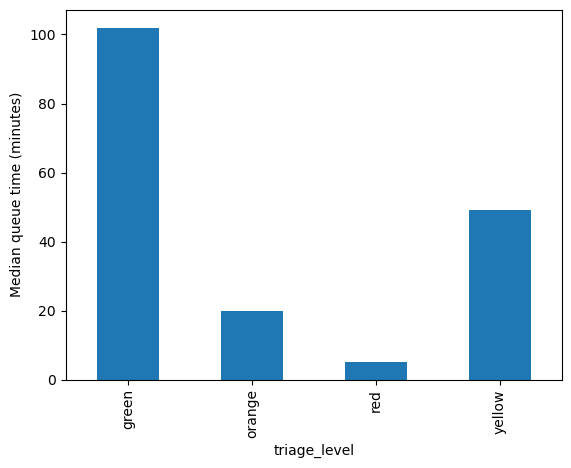

In [2]:

df.groupby("triage_level")["queue_time_minutes"].median().plot(kind="bar")
plt.ylabel("Median queue time (minutes)")
plt.show()


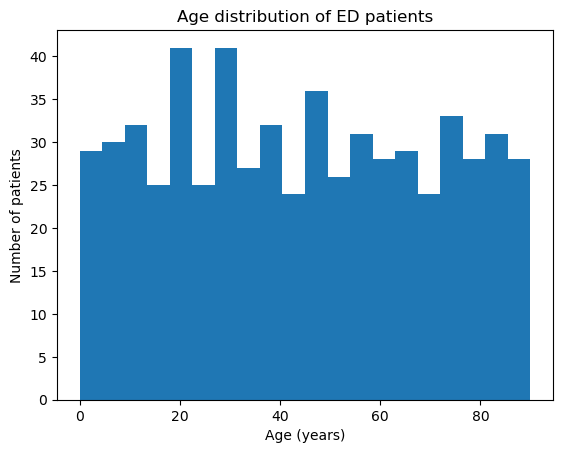

In [4]:
plt.hist(df["age"], bins=20)
plt.xlabel("Age (years)")
plt.ylabel("Number of patients")
plt.title("Age distribution of ED patients")
plt.show()


## Length of stay by disposition

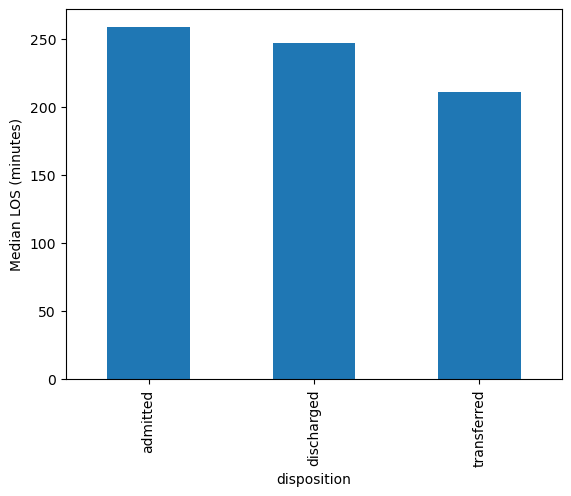

In [3]:

df.groupby("disposition")["length_of_stay_minutes"].median().plot(kind="bar")
plt.ylabel("Median LOS (minutes)")
plt.show()


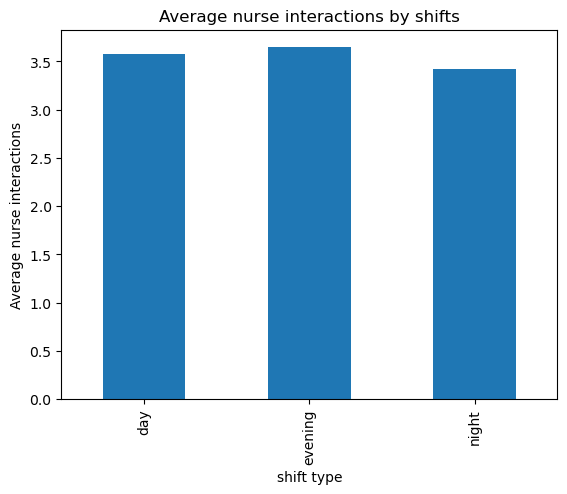

In [5]:
df.groupby("shift_type")["nurse_interactions"].mean().plot(kind="bar")
plt.xlabel("shift type")
plt.ylabel("Average nurse interactions")
plt.title ("Average nurse interactions by shifts")
plt.show()

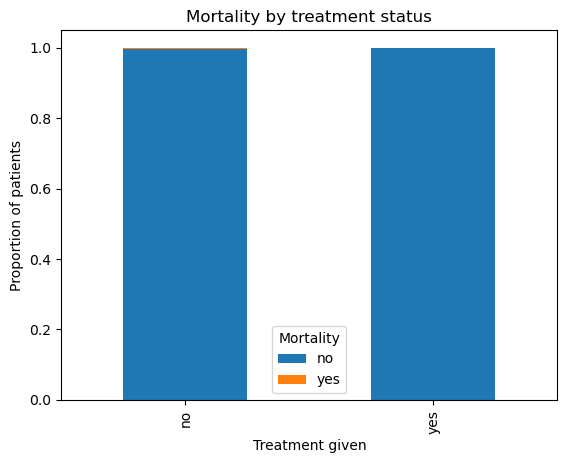

In [6]:
pd.crosstab(
    df["treatment_given"],
    df["mortality"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.xlabel("Treatment given")
plt.ylabel("Proportion of patients")
plt.title("Mortality by treatment status")
plt.legend(title="Mortality")
plt.show()


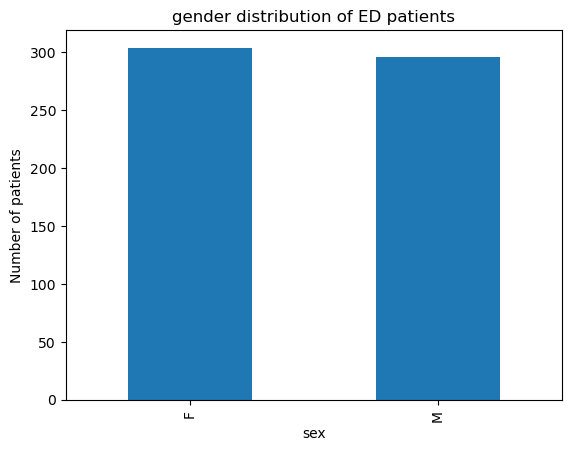

In [7]:
df["sex"].value_counts().plot(kind="bar")
plt.xlabel("sex")
plt.ylabel("Number of patients")
plt.title("gender distribution of ED patients")
plt.show()

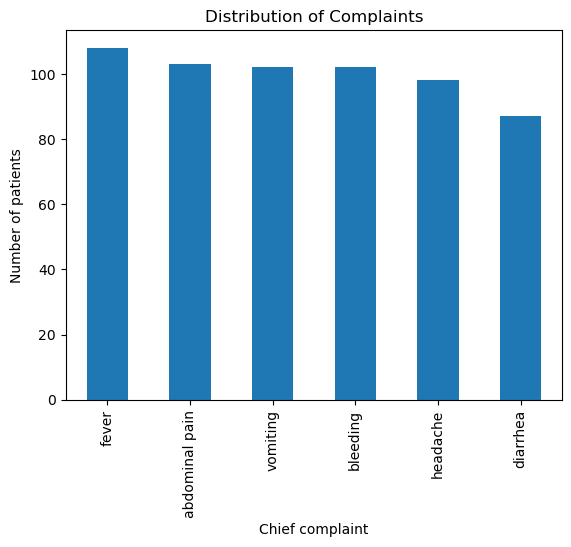

In [9]:
df["chief_complaint"].value_counts().plot(kind="bar")
plt.xlabel("Chief complaint")
plt.ylabel("Number of patients")
plt.title("Distribution of Complaints")
plt.show()


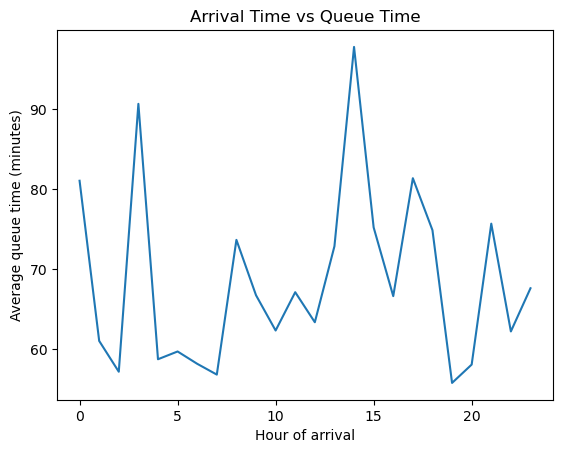

In [10]:
df["arrival_time"] = pd.to_datetime(df["arrival_time"])
df["arrival_hour"] = df["arrival_time"].dt.hour

df.groupby("arrival_hour")["queue_time_minutes"].mean().plot()
plt.xlabel("Hour of arrival")
plt.ylabel("Average queue time (minutes)")
plt.title("Arrival Time vs Queue Time")
plt.show()


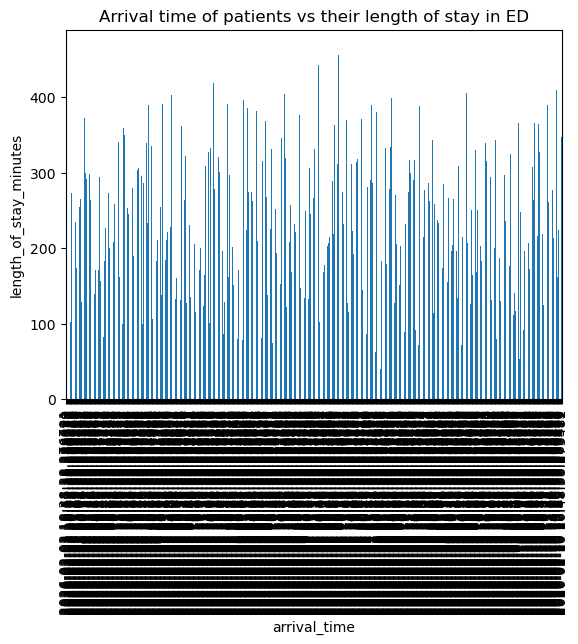

In [11]:
df.groupby("arrival_time")["length_of_stay_minutes"].mean().plot(kind="bar")
plt.xlabel("arrival_time")
plt.ylabel("length_of_stay_minutes")
plt.title("Arrival time of patients vs their length of stay in ED")
plt.show()


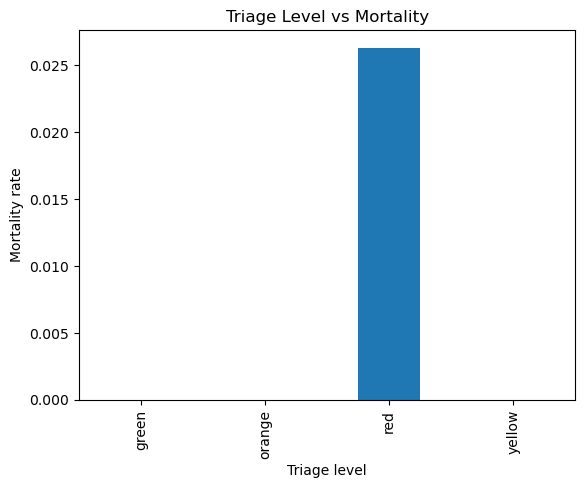

In [12]:
mortality_by_triage = (
    df.groupby("triage_level")["mortality"]
    .apply(lambda x: (x == "yes").mean())  
)

mortality_by_triage.plot(kind="bar")
plt.xlabel("Triage level")
plt.ylabel("Mortality rate")
plt.title("Triage Level vs Mortality")
plt.show()
